# Consumption error-correction model — self-contained

A compact, standalone build of the final consumption ECM. Everything (FRED download, long-run
cointegration, short-run dynamics, backtests, forecast, time-varying wealth effect) is in this
notebook — no project modules required.

**Model.** Two-step Engle–Granger ECM for real personal consumption growth `Δc`:

* **Long run** — ratio cointegration `c − y = a + b·(w − y)` with a **2012Q1 break** in the
  wealth elasticity `b` (the break used in the Fed FEDS note), homogeneity imposed, COVID
  excluded from estimation. The residual is the error-correction term (ECT).
* **Short run** — `Δc = const + Δc₋₁ + Δy + Δy₋₁ + Δw + Δw₋₁ + Δu + ECT₋₁`, OLS with
  HAC/Newey–West (4 lags) standard errors. (The real interest rate was tested but added nothing
  to fit or out-of-sample RMSE, so the final spec keeps only the change in unemployment.)

In [1]:
%matplotlib inline
import json
from urllib.request import urlopen
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson, jarque_bera
import matplotlib.pyplot as plt

FRED_KEY = "51f3ac7bc8b65cb6bb2589fc570292be"
Q = lambda s: pd.Period(s, freq="Q")
BREAK, COVID0, COVID1 = Q("2012Q1"), Q("2020Q2"), Q("2021Q2")
is_covid = lambda ix: (ix >= COVID0) & (ix <= COVID1)

def fred(series_id, how="mean"):
    url = (f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}"
           f"&api_key={FRED_KEY}&file_type=json&observation_start=1985-01-01")
    obs = json.loads(urlopen(url, timeout=30).read())["observations"]
    d = pd.DataFrame(obs)
    d = d[d["value"] != "."].copy()
    d["q"] = pd.to_datetime(d["date"]).dt.to_period("Q")
    g = d.assign(value=d["value"].astype(float)).groupby("q")["value"]
    return g.last() if how == "last" else g.mean()

## 1. Data — FRED, 1990Q1–2026Q1

Real PCE (`PCECC96`), real disposable income (`DPIC96`), household net worth (`TNWBSHNO`,
deflated by `PCEPI`) and unemployment (`UNRATE`). Logs `c, y, w`; ratios `cy = c−y`, `wy = w−y`.

In [2]:
raw = pd.DataFrame({
    "C_real": fred("PCECC96"),          # real PCE, $bn, annual rate
    "YD_real": fred("DPIC96"),          # real disposable income, $bn
    "W_nom": fred("TNWBSHNO", "last"),  # household net worth, $mn
    "P": fred("PCEPI"),                 # PCE price index
    "u": fred("UNRATE"),                # unemployment rate, %
}).sort_index()

raw["W_real"] = raw["W_nom"] / (raw["P"] / 100.0)     # real net worth, $mn
raw["c"], raw["y"], raw["w"] = np.log(raw["C_real"]), np.log(raw["YD_real"]), np.log(raw["W_real"])
raw["cy"], raw["wy"] = raw["c"] - raw["y"], raw["w"] - raw["y"]
raw["D2012"] = (raw.index >= BREAK).astype(float)
anchor = raw.loc[Q("2011Q4"), "wy"]                   # wy level just before the break
raw["wy_post_centered"] = raw["D2012"] * (raw["wy"] - anchor)
# differences and lags computed on the full series so 1990Q1 already has valid lags
raw["dc"], raw["dy"], raw["dw"], raw["du"] = raw["c"].diff(), raw["y"].diff(), raw["w"].diff(), raw["u"].diff()
raw["dc_l1"], raw["dy_l1"], raw["dw_l1"] = raw["dc"].shift(1), raw["dy"].shift(1), raw["dw"].shift(1)
raw["dy_l0"], raw["dw_l0"], raw["du_l0"] = raw["dy"], raw["dw"], raw["du"]

df = raw.loc[Q("1990Q1"):Q("2026Q1")].copy()          # estimation sample
print(f"Sample: {df.index.min()} .. {df.index.max()}  ({len(df)} quarters)")
df[["C_real", "YD_real", "W_real", "c", "y", "w", "cy", "wy", "u"]].tail(4).round(3)

Sample: 1990Q1 .. 2026Q1  (145 quarters)


,C_real,YD_real,W_real,c,y,w,cy,wy,u
q,,,,,,,,,
2025Q2,16445.685,18025.143,1.391592e+08,9.708,9.800,18.751,-0.092,8.952,4.200
2025Q3,16585.878,18070.788,1.422998e+08,9.716,9.802,18.773,-0.086,8.971,4.333
2025Q4,16665.219,18030.244,1.426422e+08,9.721,9.800,18.776,-0.079,8.976,4.450
2026Q1,16723.347,18066.372,1.411508e+08,9.725,9.802,18.765,-0.077,8.964,4.333


## 2. Long run — cointegration with a 2012 break in the wealth elasticity

OLS of `cy` on `[D2012, wy, wy_post_centered]` (COVID excluded). The wealth elasticity of
consumption is the slope of `c−y` on `w−y` (`∂ln C/∂ln W = b`): `b_pre` before 2012,
`b_pre + shift` after. The ECT is `cy − fitted`.

const              -1.9468
D2012              -0.0055
wy                  0.2137
wy_post_centered   -0.1545

Wealth elasticity  pre-2012 = 0.214   post-2012 = 0.059   (no-break = 0.075)


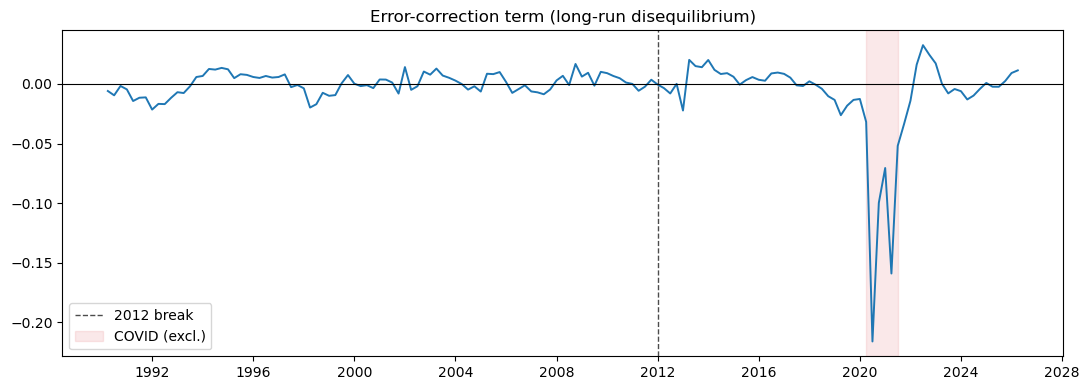

In [3]:
LR = ["D2012", "wy", "wy_post_centered"]

def lr_params(train):
    s = train[~is_covid(train.index)][["cy"] + LR].dropna()
    return sm.OLS(s["cy"], sm.add_constant(s[LR])).fit().params

def lr_target(p, data):     # fitted long-run cy
    return p["const"] + p["D2012"] * data["D2012"] + p["wy"] * data["wy"] + p["wy_post_centered"] * data["wy_post_centered"]

p_lr = lr_params(df)
df["ECT"] = df["cy"] - lr_target(p_lr, df)
df["ECT_l1"] = df["ECT"].shift(1)

b_pre = p_lr["wy"]
b_post = p_lr["wy"] + p_lr["wy_post_centered"]
sb = df[~is_covid(df.index)][["cy", "wy"]].dropna()
b_nobreak = sm.OLS(sb["cy"], sm.add_constant(sb["wy"])).fit().params["wy"]

print(p_lr.round(4).to_string())
print(f"\nWealth elasticity  pre-2012 = {b_pre:.3f}   post-2012 = {b_post:.3f}   (no-break = {b_nobreak:.3f})")

fig, ax = plt.subplots(figsize=(11, 4))
x = df.index.to_timestamp(how="end")
ax.plot(x, df["ECT"], color="tab:blue", lw=1.4)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(BREAK.to_timestamp(), color="black", ls="--", lw=1, alpha=0.7, label="2012 break")
ax.axvspan(COVID0.to_timestamp(), (COVID1 + 1).to_timestamp(), color="tab:red", alpha=0.1, label="COVID (excl.)")
ax.set_title("Error-correction term (long-run disequilibrium)"); ax.legend(); fig.tight_layout(); plt.show()

### Residual stationarity — Engle–Granger / Gregory–Hansen cointegration test

A two-step ECM is valid only if the long-run residual (the ECT) is **stationary** — otherwise the
"long-run relationship" is spurious and `ECT₋₁` carries no error-correction information.

The ordinary `adfuller` *p-value* is **not** valid for a residual from an *estimated*
cointegrating vector (it over-rejects), so we compare the ADF **t-statistic** to the correct
cointegration critical values: Engle–Granger/MacKinnon for the no-break ratio, and Gregory–Hansen
(1996, Table 1, regime-shift model C/S) for the break specification — the GH values are more
demanding because the break date is searched rather than known.

In [4]:
from statsmodels.tsa.stattools import adfuller, coint

# Engle-Granger step 2: the ECM is valid only if the long-run residual (the ECT) is STATIONARY,
# otherwise the relationship is spurious. The raw `adfuller` p-value is NOT valid for a residual
# from an *estimated* cointegrating vector, so we compare the ADF t-stat to cointegration
# critical values (Engle-Granger/MacKinnon for the no-break ratio; Gregory-Hansen for the break).
nc_idx = ~is_covid(df.index)

# (a) no-break ratio cy ~ wy -- MacKinnon p-value is valid here
sb_ = df[nc_idx][["cy", "wy"]].dropna()
eg_t, eg_p, eg_cv = coint(sb_["cy"], sb_["wy"], trend="c", autolag="AIC")

# (b) final-model ECT (imposed 2012 break): ADF on the residual, no deterministics
adf_t = adfuller(df["ECT"][nc_idx].dropna(), regression="n", autolag="AIC")[0]

# (c) Gregory-Hansen regime-shift test: min ADF over candidate (endogenous) break dates
def gh_inf_adf(sample, trim=0.15):
    cl = sample[["cy", "wy"]].dropna().sort_index()
    cy, wy, n = cl["cy"].values, cl["wy"].values, len(cl)
    best = (np.inf, None)
    for k in range(int(np.ceil(trim * n)), int(np.floor((1 - trim) * n))):
        D = (np.arange(n) >= k).astype(float)
        X = np.column_stack([np.ones(n), D, wy, D * wy])
        resid = cy - X @ np.linalg.lstsq(X, cy, rcond=None)[0]
        t = adfuller(resid, regression="n", autolag="AIC")[0]
        if t < best[0]:
            best = (t, cl.index[k])
    return best
gh_t, gh_break = gh_inf_adf(df[nc_idx])

print("Residual stationarity / cointegration tests (Engle-Granger 2-step, COVID excluded)")
print("-" * 78)
print(f"(a) No-break  cy ~ wy        Engle-Granger t = {eg_t:+.3f}   p = {eg_p:.4f}")
print(f"      MacKinnon crit: 1% {eg_cv[0]:.2f}  5% {eg_cv[1]:.2f}  10% {eg_cv[2]:.2f}   -> cointegrated at 5%: {eg_t < eg_cv[1]}")
print(f"(b) Final ECT (2012 break)   ADF t = {adf_t:+.3f}   (no deterministics)")
print(f"      vs Gregory-Hansen C/S crit -> rejects unit root at 5%: {adf_t < -4.95}")
print(f"(c) Gregory-Hansen inf-ADF   ADF* t = {gh_t:+.3f}   at endogenous break {gh_break}")
print(f"      GH C/S crit (m=1): 1% -5.47  5% -4.95  10% -4.68   -> rejects at 5%: {gh_t < -4.95}")
print("\nVerdict: all tests reject a unit root in the residual -> the long-run relationship is a")
print("valid cointegration, so the ECT is a legitimate error-correction term (cf. alpha<0, sig.).")

Residual stationarity / cointegration tests (Engle-Granger 2-step, COVID excluded)
------------------------------------------------------------------------------
(a) No-break  cy ~ wy        Engle-Granger t = -3.539   p = 0.0291
      MacKinnon crit: 1% -3.98  5% -3.38  10% -3.08   -> cointegrated at 5%: True
(b) Final ECT (2012 break)   ADF t = -5.026   (no deterministics)
      vs Gregory-Hansen C/S crit -> rejects unit root at 5%: True
(c) Gregory-Hansen inf-ADF   ADF* t = -5.217   at endogenous break 2008Q3
      GH C/S crit (m=1): 1% -5.47  5% -4.95  10% -4.68   -> rejects at 5%: True

Verdict: all tests reject a unit root in the residual -> the long-run relationship is a
valid cointegration, so the ECT is a legitimate error-correction term (cf. alpha<0, sig.).


## 3. Short-run ECM (HAC inference)

In [5]:
SR = ["dc_l1", "dy_l0", "dy_l1", "dw_l0", "dw_l1", "du_l0", "ECT_l1"]
predict = lambda res, row: float(sum((1.0 if k == "const" else row[k]) * res.params[k] for k in res.params.index))

s = df[["dc"] + SR].dropna()
res = sm.OLS(s["dc"], sm.add_constant(s[SR])).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

coef = pd.DataFrame({"coef": res.params, "HAC_se": res.bse, "t": res.tvalues, "p": res.pvalues})
print(coef.round(4).to_string())

alpha = res.params["ECT_l1"]
nc = ~is_covid(res.resid.index)
print(f"\nObs {int(res.nobs)} ({s.index.min()}..{s.index.max()})   adj.R2 {res.rsquared_adj:.3f}   BIC {res.bic:.1f}")
print(f"ECT (alpha) {alpha:+.4f}  (HAC p {res.pvalues['ECT_l1']:.4f})   half-life {np.log(0.5)/np.log(1+alpha):.1f} q   valid ECM {alpha < 0 and res.pvalues['ECT_l1'] < 0.10}")
print(f"In-sample RMSE ex-COVID {np.sqrt(np.mean((400*res.resid[nc])**2)):.3f} ann. pp")
print(f"Diagnostics: Breusch-Godfrey(4) p {acorr_breusch_godfrey(res, nlags=4)[1]:.3f}   "
      f"Jarque-Bera p {jarque_bera(res.resid)[1]:.3f}   Durbin-Watson {durbin_watson(res.resid):.2f}")

          coef  HAC_se        t       p
const   0.0052  0.0006   8.4587  0.0000
dc_l1  -0.0981  0.0315  -3.1094  0.0019
dy_l0   0.0577  0.0205   2.8143  0.0049
dy_l1   0.1443  0.0240   6.0111  0.0000
dw_l0   0.0354  0.0253   1.3950  0.1630
dw_l1   0.0338  0.0190   1.7810  0.0749
du_l0  -0.0109  0.0007 -16.2158  0.0000
ECT_l1 -0.0514  0.0220  -2.3351  0.0195

Obs 144 (1990Q2..2026Q1)   adj.R2 0.856   BIC -1115.1
ECT (alpha) -0.0514  (HAC p 0.0195)   half-life 13.1 q   valid ECM True
In-sample RMSE ex-COVID 1.744 ann. pp
Diagnostics: Breusch-Godfrey(4) p 0.000   Jarque-Bera p 0.000   Durbin-Watson 1.58


## 4. In-sample fit

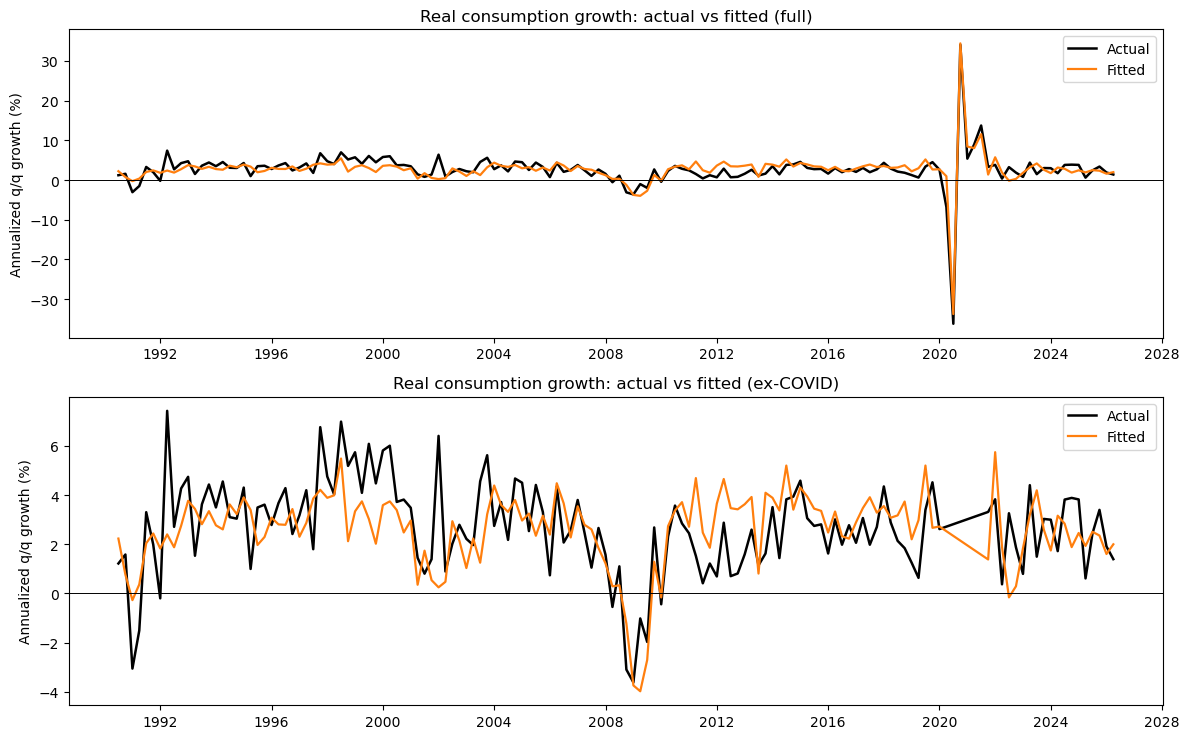

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5))
act, fit_ = 400 * s["dc"], 400 * res.fittedvalues
for ax, zoom in zip(axes, [False, True]):
    keep = ~s.index.to_series().between(Q("2020Q1"), COVID1) if zoom else pd.Series(True, index=s.index)
    xx = s.index[keep.values].to_timestamp(how="end")
    ax.plot(xx, act[keep.values], color="black", lw=1.8, label="Actual")
    ax.plot(xx, fit_[keep.values], color="tab:orange", lw=1.6, label="Fitted")
    ax.axhline(0, color="black", lw=0.7); ax.legend()
    ax.set_ylabel("Annualized q/q growth (%)")
    ax.set_title("Real consumption growth: actual vs fitted" + (" (ex-COVID)" if zoom else " (full)"))
fig.tight_layout(); plt.show()

### Out-of-sample fit (from 2023Q1)

Here the coefficients — long-run **and** short-run — are estimated **once** on data through
2022Q4 and then applied to the **actual, realized** values of the independent variables for
2023Q1 onward. It is a static, one-step-ahead fit conditional on known regressors (the lagged
`Δc` and the `ECT₋₁` use realized data, not forecasts). This differs from the recursive backtest
in Section 5, which re-estimates at every origin and feeds its own forecasts back as lags.

Out-of-sample fit 2023Q1..2026Q1  (coefficients fixed at 2022Q4, actual regressors)
  quarters = 13   RMSE = 1.334 annualized pp

        actual_ann_pct  oos_fit_ann_pct
2023Q1            4.40             3.25
2023Q2            1.49             4.27
2023Q3            3.03             2.58
2023Q4            3.00             1.75
2024Q1            1.72             3.16
2024Q2            3.81             2.82
2024Q3            3.88             1.88
2024Q4            3.82             2.45
2025Q1            0.61             1.94
2025Q2            2.44             2.51
2025Q3            3.40             2.33
2025Q4            1.91             1.59
2026Q1            1.39             1.98


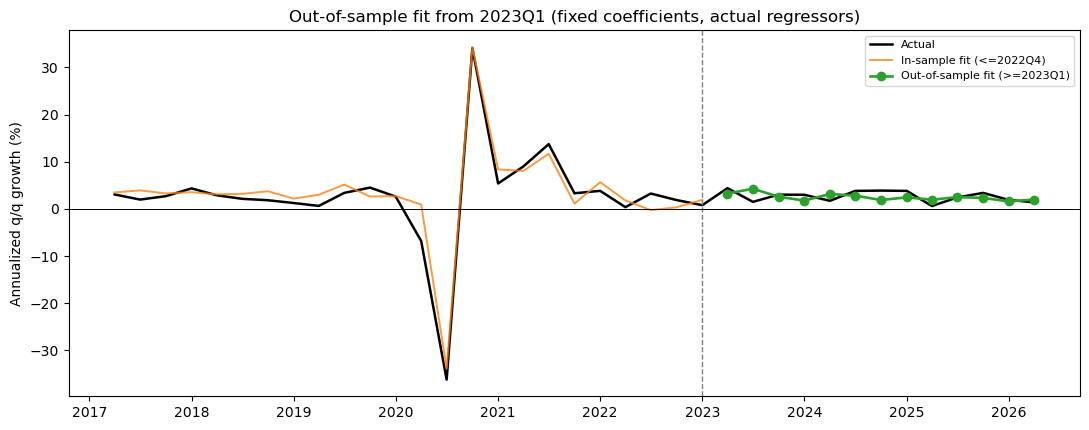

In [7]:
# Out-of-sample fit: estimate coefficients ONCE through 2022Q4, then apply them to the actual
# (known) regressors for 2023Q1 onward. No re-estimation, no feeding forecasts back (cf. Sec. 5).
TRAIN_END, OOS_START = Q("2022Q4"), Q("2023Q1")

p_tr = lr_params(df.loc[:TRAIN_END])                              # long-run coeffs, training only
d_oos = df.assign(ECT_l1=(df["cy"] - lr_target(p_tr, df)).shift(1))
tr = d_oos.loc[:TRAIN_END][["dc"] + SR].dropna()
res_tr = sm.OLS(tr["dc"], sm.add_constant(tr[SR])).fit()         # short-run coeffs, training only

oos = d_oos.loc[OOS_START:]
oos_pred = pd.Series({q: predict(res_tr, oos.loc[q]) for q in oos.index})
rmse_oos = float(np.sqrt(np.mean((400 * (oos["dc"] - oos_pred)) ** 2)))

print(f"Out-of-sample fit {OOS_START}..{df.index.max()}  (coefficients fixed at {TRAIN_END}, actual regressors)")
print(f"  quarters = {len(oos)}   RMSE = {rmse_oos:.3f} annualized pp\n")
print(pd.DataFrame({"actual_ann_pct": (400 * oos["dc"]).round(2),
                    "oos_fit_ann_pct": (400 * oos_pred).round(2)}).to_string())

fig, ax = plt.subplots(figsize=(11, 4.4))
hh = df[df.index >= Q("2017Q1")]
ax.plot(hh.index.to_timestamp(how="end"), 400 * hh["dc"], color="black", lw=1.8, label="Actual")
ft = res_tr.fittedvalues
ft = ft[ft.index >= Q("2017Q1")]
ax.plot(ft.index.to_timestamp(how="end"), 400 * ft, color="tab:orange", lw=1.4, alpha=0.8, label="In-sample fit (<=2022Q4)")
ax.plot(oos_pred.index.to_timestamp(how="end"), 400 * oos_pred, "o-", color="tab:green", lw=1.9, label="Out-of-sample fit (>=2023Q1)")
ax.axvline(TRAIN_END.to_timestamp(how="end"), color="gray", ls="--", lw=1)
ax.axhline(0, color="black", lw=0.7)
ax.set_title("Out-of-sample fit from 2023Q1 (fixed coefficients, actual regressors)")
ax.set_ylabel("Annualized q/q growth (%)"); ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 5. Out-of-sample backtests

Long-run **and** short-run re-estimated at every origin (no look-ahead), conditional on the
realized paths of income, wealth and unemployment. One-step from 2015Q1; Q4/Q4 from 2015.

One-step RMSE ex-COVID : 2.090 ann. pp   (n=40)
Q4/Q4    RMSE ex-COVID : 0.829 pp        (n=9)


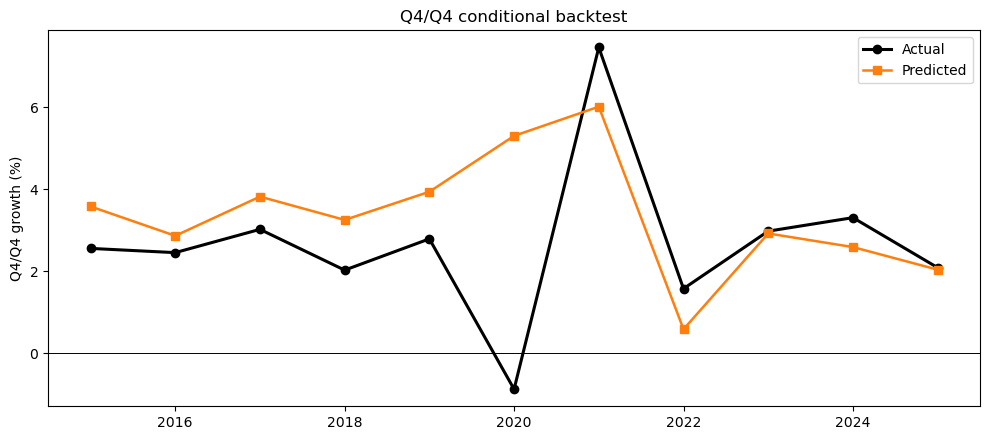

In [8]:
def fit_sr(data):
    s = data[["dc"] + SR].dropna()
    return sm.OLS(s["dc"], sm.add_constant(s[SR])).fit()

def one_step():
    out = []
    for q in df.index[df.index >= Q("2015Q1")]:
        o = q - 1
        tgt = lr_target(lr_params(df.loc[:o]), df)
        d = df.assign(ECT_l1=(df["cy"] - tgt).shift(1))
        out.append((q, df.loc[q, "dc"], predict(fit_sr(d.loc[:o]), d.loc[q])))
    return pd.DataFrame(out, columns=["q", "actual", "pred"])

def q4q4():
    out = []
    for Yr in range(2015, 2026):
        o, tg = Q(f"{Yr-1}Q4"), [Q(f"{Yr}Q{i}") for i in (1, 2, 3, 4)]
        if o not in df.index or any(t not in df.index for t in tg):
            continue
        prm = lr_params(df.loc[:o]); tgt = lr_target(prm, df)
        d = df.assign(ECT_l1=(df["cy"] - tgt).shift(1)); sr = fit_sr(d.loc[:o])
        cfc, dcfc = {o: df.loc[o, "c"]}, {}
        for q in tg:
            r = d.loc[q].to_dict()
            r["dc_l1"] = dcfc.get(q - 1, df.loc[q - 1, "dc"])
            r["ECT_l1"] = (cfc[q - 1] - df.loc[q - 1, "y"]) - tgt[q - 1]
            dq = predict(sr, r); cfc[q] = cfc[q - 1] + dq; dcfc[q] = dq
        out.append((Yr, 100 * (df.loc[tg[-1], "c"] - df.loc[o, "c"]), 100 * (cfc[tg[-1]] - df.loc[o, "c"])))
    return pd.DataFrame(out, columns=["year", "actual", "pred"])

os1, q4 = one_step(), q4q4()
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))
e1 = 400 * (os1["actual"] - os1["pred"])[~is_covid(pd.PeriodIndex(os1["q"]))]
e4 = (q4["actual"] - q4["pred"])[~q4["year"].isin([2020, 2021])]
print(f"One-step RMSE ex-COVID : {rmse(e1):.3f} ann. pp   (n={len(e1)})")
print(f"Q4/Q4    RMSE ex-COVID : {rmse(e4):.3f} pp        (n={len(e4)})")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(q4["year"], q4["actual"], "o-", color="black", lw=2.2, label="Actual")
ax.plot(q4["year"], q4["pred"], "s-", color="tab:orange", lw=1.8, label="Predicted")
ax.axhline(0, color="black", lw=0.7); ax.set_title("Q4/Q4 conditional backtest")
ax.set_ylabel("Q4/Q4 growth (%)"); ax.legend(); fig.tight_layout(); plt.show()

## 6. Eight-quarter recursive forecast (2026Q2 → 2028Q1)

The ECM is iterated forward one quarter at a time, feeding its own `Δc` back as the lag and
re-deriving `ECT₋₁` from the projected consumption level. The forecast is **conditional** on a
scenario for income, wealth and unemployment — defaults are the trailing 5-year (ex-COVID)
average growth; unemployment held flat. **Edit `scenario` to explore alternatives.**

In [9]:
recent = df[~is_covid(df.index)].tail(20)
scenario = {"dy_annual_pct": round(recent["dy"].mean() * 400, 2),
            "dw_annual_pct": round(recent["dw"].mean() * 400, 2),
            "du_quarterly": 0.0}
print("Scenario:", scenario)
dy_q, dw_q, du_q = scenario["dy_annual_pct"] / 400, scenario["dw_annual_pct"] / 400, scenario["du_quarterly"]

last = df.index.max()
st = {k: {last: float(df.loc[last, k])} for k in ["c", "y", "w", "dc", "dy", "dw"]}
rows = []
for h in range(1, 9):
    q, pv = last + h, last + h - 1
    st["dy"][q], st["dw"][q] = dy_q, dw_q
    st["y"][q], st["w"][q] = st["y"][pv] + dy_q, st["w"][pv] + dw_q
    wy_pv = st["w"][pv] - st["y"][pv]
    ect_l1 = (st["c"][pv] - st["y"][pv]) - (p_lr["const"] + p_lr["D2012"] + p_lr["wy"] * wy_pv
                                            + p_lr["wy_post_centered"] * (wy_pv - anchor))
    feats = {"dc_l1": st["dc"][pv], "dy_l0": dy_q, "dy_l1": st["dy"][pv],
             "dw_l0": dw_q, "dw_l1": st["dw"][pv], "du_l0": du_q, "ECT_l1": ect_l1}
    dq = predict(res, feats)
    st["dc"][q], st["c"][q] = dq, st["c"][pv] + dq
    rows.append({"quarter": str(q), "dc_ann_pct": 400 * dq, "ECT_l1": ect_l1,
                 "PCE_index": np.exp(st["c"][q] - float(df.loc[last, "c"])) * 100})
fc = pd.DataFrame(rows).set_index("quarter")
band = 400 * res.resid.std()
print(f"Cumulative real PCE growth over 8 quarters: {100*(st['c'][last+8]-st['c'][last]):.2f}%")
fc.round(3)

Scenario: {'dy_annual_pct': np.float64(1.26), 'dw_annual_pct': np.float64(0.1), 'du_quarterly': 0.0}
Cumulative real PCE growth over 8 quarters: 3.57%


,dc_ann_pct,ECT_l1,PCE_index
quarter,,,
2026Q2,1.743,0.011,100.437
2026Q3,1.892,0.013,100.913
2026Q4,1.841,0.014,101.378
2027Q1,1.813,0.016,101.839
2027Q2,1.784,0.018,102.294
2027Q3,1.756,0.019,102.744
2027Q4,1.730,0.021,103.189
2028Q1,1.705,0.022,103.630


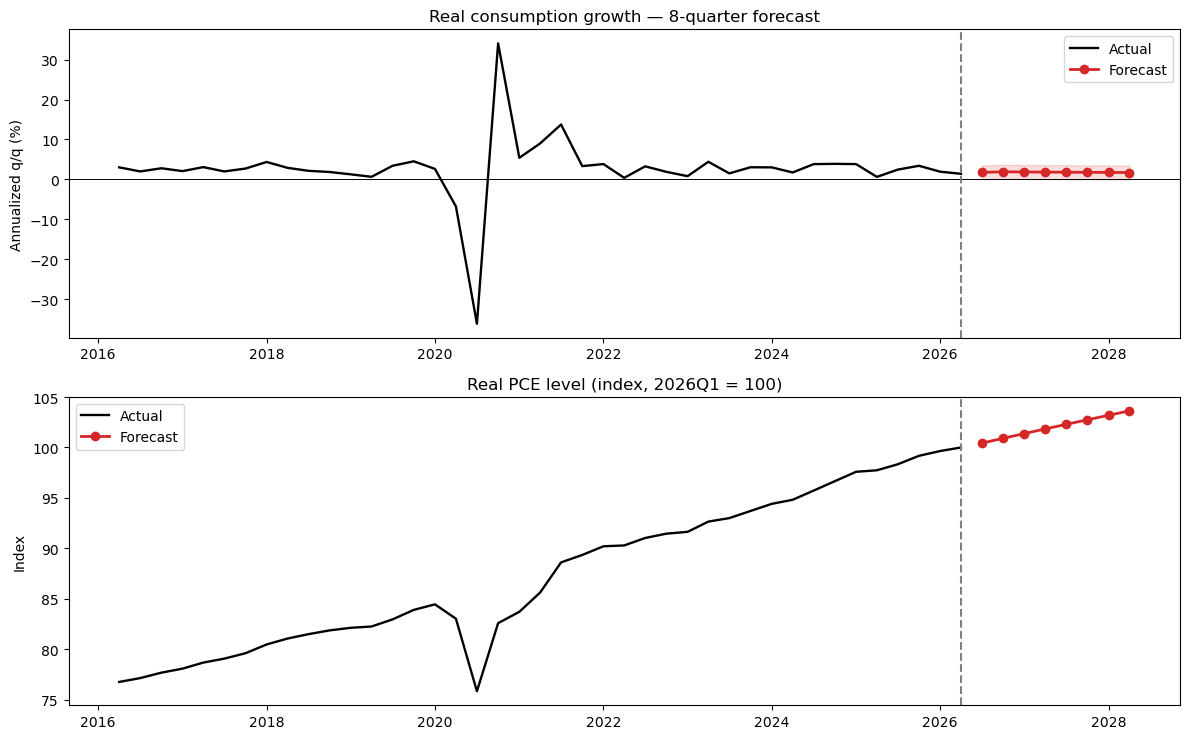

In [10]:
fcd = pd.PeriodIndex(fc.index, freq="Q").to_timestamp(how="end")
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5))
h0 = df[df.index >= Q("2016Q1")]
hx = h0.index.to_timestamp(how="end")
axes[0].plot(hx, 400 * h0["dc"], color="black", lw=1.7, label="Actual")
axes[0].plot(fcd, fc["dc_ann_pct"], "o-", color="tab:red", lw=2, label="Forecast")
axes[0].fill_between(fcd, fc["dc_ann_pct"] - band, fc["dc_ann_pct"] + band, color="tab:red", alpha=0.15)
axes[0].axhline(0, color="black", lw=0.7); axes[0].axvline(last.to_timestamp(how="end"), color="gray", ls="--")
axes[0].set_title("Real consumption growth — 8-quarter forecast"); axes[0].set_ylabel("Annualized q/q (%)"); axes[0].legend()

lvl = np.exp(h0["c"] - float(df.loc[last, "c"])) * 100
axes[1].plot(hx, lvl, color="black", lw=1.7, label="Actual")
axes[1].plot(fcd, fc["PCE_index"], "o-", color="tab:red", lw=2, label="Forecast")
axes[1].axvline(last.to_timestamp(how="end"), color="gray", ls="--")
axes[1].set_title(f"Real PCE level (index, {last} = 100)"); axes[1].set_ylabel("Index"); axes[1].legend()
fig.tight_layout(); plt.show()

## 7. Time-varying wealth elasticity and MPC out of wealth (10-year rolling)

A trailing 40-quarter (10-year) rolling regression of `cy` on `wy` (COVID excluded) gives a
continuously time-varying wealth elasticity `b_t`. The marginal propensity to consume out of
wealth converts it to dollars: `MPC = ∂C/∂W = b_t · C/W`, shown in **cents of annual
consumption per dollar of net worth** (real PCE is $bn at an annual rate, net worth is $mn — put
on the same basis before the ratio).

Wealth elasticity: 0.202 (1999Q4) -> 0.085 (2026Q1)
MPC (cents/$):     3.02 -> 1.01


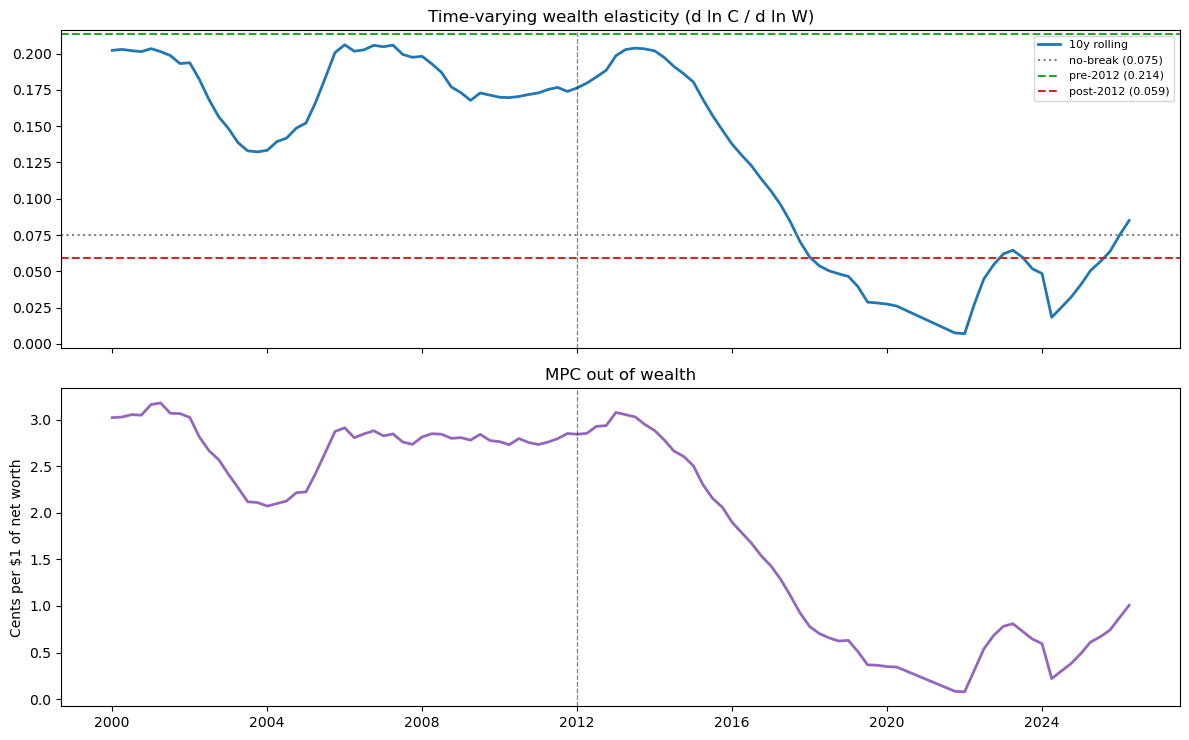

In [11]:
base = df[~is_covid(df.index)][["cy", "wy", "C_real", "W_real"]].dropna()
roll = {base.index[i-1]: np.polyfit(base["wy"].iloc[i-40:i], base["cy"].iloc[i-40:i], 1)[0]
        for i in range(40, len(base) + 1)}
bw_t = pd.Series(roll).sort_index()
cw = (df["C_real"] * 1e9) / (df["W_real"] * 1e6)        # dollars of annual PCE per $ of wealth
mpc_cents = 100 * bw_t * cw.reindex(bw_t.index)

print(f"Wealth elasticity: {bw_t.iloc[0]:.3f} ({bw_t.index[0]}) -> {bw_t.iloc[-1]:.3f} ({bw_t.index[-1]})")
print(f"MPC (cents/$):     {mpc_cents.iloc[0]:.2f} -> {mpc_cents.iloc[-1]:.2f}")

xt = bw_t.index.to_timestamp(how="end")
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)
axes[0].plot(xt, bw_t.values, color="tab:blue", lw=2, label="10y rolling")
axes[0].axhline(b_nobreak, color="gray", ls=":", label=f"no-break ({b_nobreak:.3f})")
axes[0].axhline(b_pre, color="tab:green", ls="--", label=f"pre-2012 ({b_pre:.3f})")
axes[0].axhline(b_post, color="tab:red", ls="--", label=f"post-2012 ({b_post:.3f})")
axes[0].set_title("Time-varying wealth elasticity (d ln C / d ln W)"); axes[0].legend(fontsize=8)
axes[1].plot(xt, mpc_cents.values, color="tab:purple", lw=2)
axes[1].set_title("MPC out of wealth"); axes[1].set_ylabel("Cents per $1 of net worth")
for a in axes:
    a.axvline(BREAK.to_timestamp(), color="black", ls="--", lw=0.9, alpha=0.5)
fig.tight_layout(); plt.show()

## 8. Summary

* Long-run cointegration with a 2012 break: wealth elasticity steps down from `b ≈ 0.21` to
  `b ≈ 0.06`; the 10-year rolling estimate traces the same decline smoothly.
* Short run is a valid ECM (negative, significant `ECT₋₁`) with good in-sample fit and the best
  Q4/Q4 out-of-sample RMSE among the candidates.
* The implied MPC out of wealth falls over the sample as both the elasticity and the
  consumption-to-wealth ratio decline.
* The 8-quarter forecast is a conditional projection — change the `scenario` in Section 6 to
  explore alternative income/wealth/unemployment paths.